In [36]:
%load_ext autoreload
%autoreload 2
import waffles
import numpy as np
import plotly.subplots as psu
import os

from waffles.data_classes.Waveform import Waveform
from waffles.data_classes.WaveformSet import WaveformSet
from waffles.data_classes.ChannelWsGrid import ChannelWsGrid
from waffles.utils.selector_waveforms import WaveformSelector
from waffles.np02_utils.load_utils import open_processed, ch_read_calib
from waffles.np02_utils.AutoMap import dict_module_to_uniqch, generate_ChannelMap
from waffles.np02_utils.PlotUtils import runBasicWfAnaNP02, wfset_remove_bad_baselines, plot_detectors
from utils import plot_tick_distributions_with_fit, plot_mpv_waveforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
dettype = "membrane"
#dettype = "cathode"

datadir = f"/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning/"
det = "VD_Cathode_PDS" if dettype == "cathode" else "VD_Membrane_PDS"
endpoint = 106 if dettype == "cathode" else 107

dletter = dettype.upper()[0] # C or M...
group1 = [ f"{dletter}{detnum}({chnum})" for detnum in range(1, 3) for chnum in range(1,3) ]
group2 = [ f"{dletter}{detnum}({chnum})" for detnum in range(3, 5) for chnum in range(1,3) ]
group3 = [ f"{dletter}{detnum}({chnum})" for detnum in range(5, 7) for chnum in range(1,3) ]
group4 = [ f"{dletter}{detnum}({chnum})" for detnum in range(7, 9) for chnum in range(1,3) ]
groupLow = group1+group2
groupHig = group3+group4
groupall = group1+group2+group3+group4

In [9]:
run_to_module = {

    "membrane" : {
        #40800 : ["M3(1)", "M3(2)"], # Mask 8, int 1600
        40801 : ["M3(1)", "M3(2)"], # Mask 8, int 2250
        40808 : ["M4(1)", "M4(2)", "M6(1)", "M6(2)"], # Mask 16, int 4000
        41522 : ["M5(1)", "M5(2)"], # Mask 16, int 3500   
        41236 : ["M7(1)", "M7(2)"], # Mask 8, int 3250 
        #40807 : ["M8(1)", "M8(2)"], # Mask 8, int 4000 
        #42062 : ["M8(1)", "M8(2)"], # !! Mask 8, int 1500 -> After swapping fibers: Mask 8 was top but here is bottom !!
        42156 : ["M8(1)", "M8(2)"], # !! Mask 8, int 2100 -> After swapping fibers !!
    },
    "cathode" : { 
       40808 : ["C1(1)", "C1(2)", "C7(1)", "C7(2)", "C8(1)", "C8(2)"], # Mask 16, int 4000
       41519 : ["C2(1)", "C2(2)"], # Mask 8, int 3000 
       41536 : ["C3(1)", "C3(2)"], # Mask 1, 2800
       #41539 : ["C4(1)", "C4(2)", "C5(1)", "C5(2)"], # Mask 16, int 1600
       42002 : ["C4(1)", "C4(2)", "C5(1)", "C5(2)"], # Mask 16, int 2400
       40807 : ["C6(1)", "C6(2)"], # Mask 8, int 4000  
    }

}
run_to_module = run_to_module[dettype]

run_to_unich = { r: [ dict_module_to_uniqch[m].channel for m in modules ] for r, modules in run_to_module.items() }
channels = [ x for v in run_to_unich.values() for x in v]

In [10]:
import copy
import time
def select_channels(waveform: Waveform, channels: list) -> bool:
    if waveform.channel not in channels:
        return False
    return True

def create_wfset(run_to_unich, endpoint):
    nwaveforms = 80000
    wfset_full = None
    for run, channels in run_to_unich.items():
        wfset = open_processed(run, dettype, datadir, channels, [endpoint], nwaveforms=nwaveforms, verbose=True)
        if wfset_full is None:
            wfset_full = copy.deepcopy(wfset)
        else:
            wfset_full.merge(copy.deepcopy(wfset))
        print(f"Loaded run {run}")
    return wfset_full
    
start = time.time()
wfset_full = create_wfset(run_to_unich, endpoint)
end = time.time()
print(end - start)
wfset_full

List of files found:
['/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run040801_membrane/processed_np02vd_raw_run040801_0000_df-s04-d0_dw_0_20251125T123158.hdf5.copied_structured_membrane.hdf5', '/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run040801_membrane/processed_np02vd_raw_run040801_0001_df-s04-d0_dw_0_20251125T123233.hdf5.copied_structured_membrane.hdf5']
📤 load_structured_waveformset returning type: <class 'waffles.data_classes.WaveformSet.WaveformSet'> with 6713 waveforms
📤 load_structured_waveformset returning type: <class 'waffles.data_classes.WaveformSet.WaveformSet'> with 6717 waveforms
Loaded run 40801
List of files found:
['/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-VD/commissioning//processed/run040808_membrane/processed_np02vd_raw_run040808_0000_df-s04-d0_dw_0_20251125T125617.hdf5.copied_structured_membrane.hdf5', '/eos/experiment/neutplatform/protodune/experiments/

WaveformSet with 90751 waveforms runs: [40801, 40808, 41236, 41522, 42156], points_per_wf: 1024, available_channels: {40801: {107: {44, 46}}, 40808: {107: {27, 41, 43, 20}}, 41522: {107: {0, 7}}, 41236: {107: {37, 30}}, 42156: {107: {17, 10}}}, record_numbers per run: run 40801: 166 records run 41522: 820 records run 41236: 132 records run 40808: 154 records run 42156: 132 records

In [ ]:
# wfsetsub = WaveformSet(*wfset_full.waveforms[:20000])

In [13]:
runBasicWfAnaNP02(wfset_full, int_ll=250, int_ul=280, amp_ll=100, amp_ul=260, threshold=25, onlyoptimal=True, configyaml="") #configyaml="ch_snr_parameters.yaml")

Processing waveform set with BasicWfAna


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90751/90751 [00:25<00:00, 3583.49it/s]


In [17]:
wfset_optimal = wfset_remove_bad_baselines(wfset_full)
wfset_optimal

WaveformSet with 79711 waveforms runs: [40801, 40808, 41236, 41522, 42156], points_per_wf: 1024, available_channels: {40801: {107: {44, 46}}, 40808: {107: {41, 27, 20, 43}}, 41522: {107: {0, 7}}, 41236: {107: {37, 30}}, 42156: {107: {17, 10}}}, record_numbers per run: run 40801: 166 records run 40808: 154 records run 42156: 132 records run 41522: 820 records run 41236: 132 records

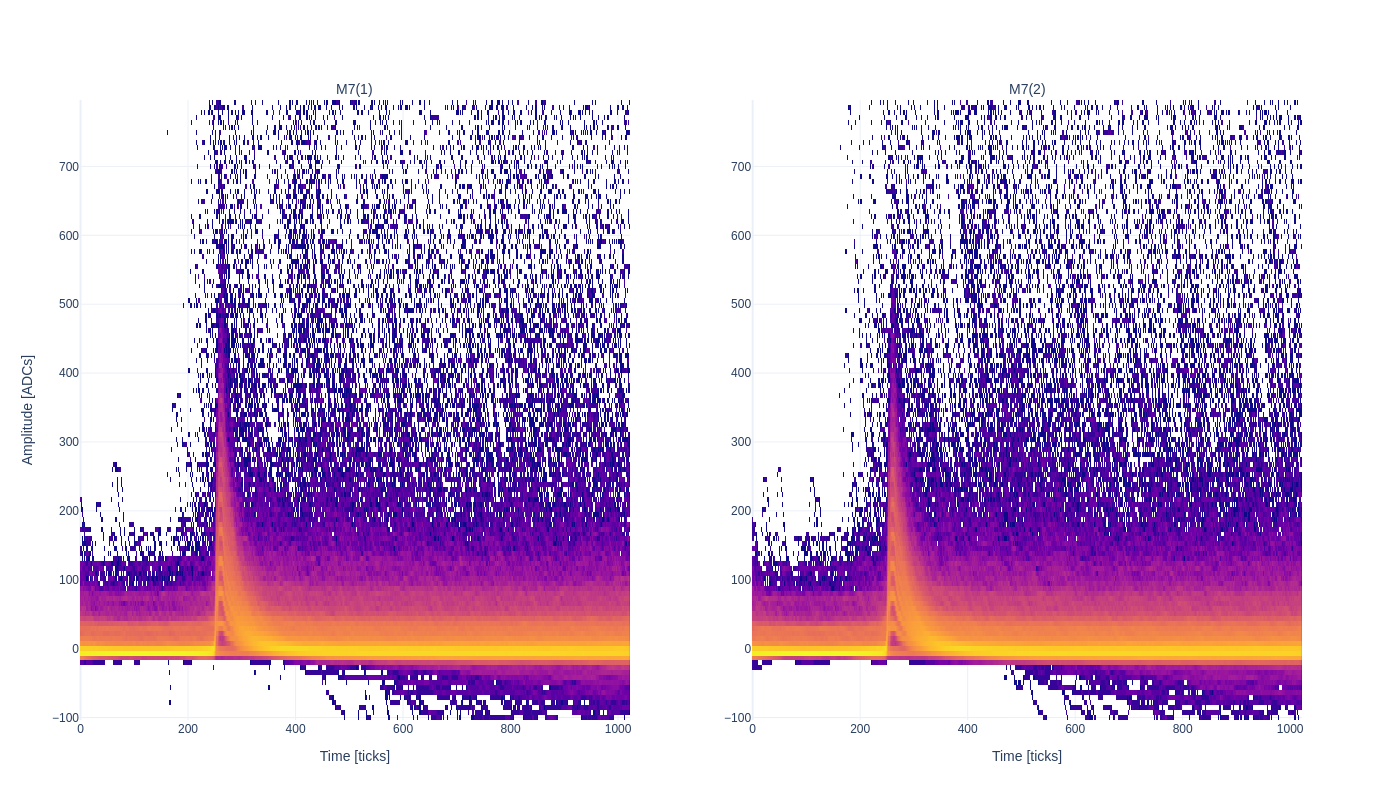

In [53]:
argsheat = dict(
    mode="heatmap",
    analysis_label="std",
    adc_range_above_baseline=800,
    adc_range_below_baseline=-100,
    adc_bins=125,
    time_bins=wfset_full.points_per_wf//2,
    filtering=36,
    share_y_scale=False,
    share_x_scale=True,
    wfs_per_axes=5000,
    zlog=True,
    width=1300,
    higth=650,
    showplots=True
)

#detector = groupLow
# detector = groupHig
#detector = groupall

detector=["M7(1)","M7(2)"]
#detector=["C2(1)"]

plot_detectors(wfset_optimal, detector, **argsheat)


In [54]:
cutyaml = 'cuts.yaml'
extractor = WaveformSelector(cutyaml)

wfset_clean = WaveformSet.from_filtered_WaveformSet(wfset_optimal, extractor.applycuts, show_progress=True)
print(f"Original waveforms: {len(wfset_optimal.waveforms)}, after cut: {len(wfset_clean.waveforms)}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79711/79711 [00:06<00:00, 11487.09it/s]


Original waveforms: 79711, after cut: 67304


In [55]:
argsheat = dict(
    mode="heatmap",
    analysis_label="std",
    adc_range_above_baseline=4000,
    adc_range_below_baseline=-250,
    adc_bins=125,
    time_bins=wfset_full.points_per_wf//2,
    filtering=36,
    share_y_scale=False,
    share_x_scale=True,
    wfs_per_axes=5000,
    zlog=True,
    width=1300,
    higth=650,
    return_fig=True,
    showplots=True
)

#detector = groupall

figs = plot_detectors(wfset_clean, detector, **argsheat)
fig, rows, cols, title, g = figs[0]

fig.show()

In [56]:
fig_distributions = psu.make_subplots(rows=g.ch_map.rows, cols=g.ch_map.columns)
plot_tick_distributions_with_fit(fig_distributions, g, tick_index=491)
fig_distributions.update_layout(template="plotly_white",
                      width=1200, height=1200, showlegend=True)

fig_distributions.show()

Computing MPV for 3925 waveforms...


Processing ticks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.82it/s]


Computing MPV for 4250 waveforms...


Processing ticks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 30.05it/s]


In [57]:
calibration_file = 'np02-config-v4.0.0.csv'
calibration_data = ch_read_calib(calibration_file)

In [ ]:
template_outputdir = waffles.__path__[0] + "/np02_data/templates/templates_large_pulses_MPV_fit/"
template_outputdir

In [ ]:
wfsetch = ChannelWsGrid.clusterize_waveform_set(wfset_clean)[endpoint]

In [ ]:
with open(template_outputdir+"cuts_used.yaml", "w") as f:
        with open(cutyaml, "r") as fcuts:
            f.write(fcuts.read())

In [ ]:
info_file = template_outputdir + f"wfdetails_{dettype}.info"

# Read existing data if file exists
existing_data = {}

if os.path.exists(info_file):
    with open(info_file, "r") as f:
        lines = f.readlines()
        for line in lines[1:]:  # Skip header line
            if line.strip():
                # Split by comma to get the main parts
                parts = line.split(", ")
                if len(parts) >= 3:
                    # The first part contains "Module endpoint-channel"
                    module_and_endpointch = parts[0].strip()
                    # Split to separate module from endpoint-channel
                    split_parts = module_and_endpointch.rsplit(" ", 1)
                    if len(split_parts) == 2:
                        module = split_parts[0]
                        endpoint_ch = split_parts[1]
                        run_num = int(parts[1].strip())
                        waveforms = int(parts[2].strip())
                        existing_data[(endpoint_ch, run_num)] = (module, waveforms)

# Update only channels that match the detector filter
for run_num, run_channels in run_to_unich.items():
    for ch in run_channels:
        module = dict_uniqch_to_module[strUch(endpoint, ch)]
        if module in detector:  # Only update if this module is in the detector list
            wfs = wfsetch[ch]
            endpoint_ch = f"{endpoint}-{ch}"
            existing_data[(endpoint_ch, run_num)] = (module, len(wfs.waveforms))

# Write back to file
with open(info_file, "w") as f:
    f.write("Module, endpoint-channel, run number, # of waveforms\n")
    for (endpoint_ch, run_num), (module, waveforms) in sorted(existing_data.items(), key=lambda x: x[1][0]):
        f.write(f"{module} {endpoint_ch}, {run_num}, {waveforms}\n")

In [58]:
#g =  ChannelWsGrid(generate_ChannelMap(["M5(1)", "M5(2)"]), wfset_clean)
#fig, rows, cols, title, g = figs[0]
fig_mpv_norm = psu.make_subplots(rows=g.ch_map.rows, cols=g.ch_map.columns)
#plot_mpv_waveforms(fig_mpv_norm, g, save=False)
plot_mpv_waveforms(fig_mpv_norm, g, calibration_data, save=False)
# plot_mpv_waveforms(fig_mpv_norm, g, calibration_data, save=False, save_dir=template_outputdir)

fig_mpv_norm.update_layout(template="plotly_white", width=1200, height=1200, showlegend=True)
fig_mpv_norm.show()

Processing channel 37...
Computing MPV for 3925 waveforms...


Processing ticks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [00:20<00:00, 49.29it/s]


Processing channel 30...
Computing MPV for 4250 waveforms...


Processing ticks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1024/1024 [00:19<00:00, 53.74it/s]
